<a href="https://colab.research.google.com/github/rileyrichmond18/is_4487_classresources/blob/main/assignment_07_RichmondRiley.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IS 4487 Assignment 7: Data Transformation with Airbnb Listings

In this assignment, you will:
- Load the Airbnb dataset you cleaned in Assignment 6
- Apply data transformation techniques like scaling, binning, encoding, and feature creation
- Make the dataset easier to use for tasks like pricing analysis, guest segmentation, or listing recommendations
- Practice writing up your analysis clearly so a business audience — like a host, marketing manager, or city partner — could understand it

## Why This Matters

Airbnb analysts, hosts, and city partners rely on clean and well-structured data to make smart decisions. Whether they’re adjusting prices, identifying high-performing listings, or designing better guest experiences, they need data that’s transformed, organized, and ready for use.

This assignment helps you practice that kind of real-world thinking: taking messy real data and getting it ready for action.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_07_data_transformation.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Dataset Description

The dataset you'll be using is a **detailed Airbnb listing file**, available from [Inside Airbnb](https://insideairbnb.com/get-the-data/).

Each row represents one property listing. The columns include:

- **Host attributes** (e.g., host ID, host name, host response time)
- **Listing details** (e.g., price, room type, minimum nights, availability)
- **Location data** (e.g., neighborhood, latitude/longitude)
- **Property characteristics** (e.g., number of bedrooms, amenities, accommodates)
- **Calendar/booking variables** (e.g., last review date, number of reviews)

The schema is consistent across cities, so you can expect similar columns regardless of the location you choose.

## 1. Setup and Load Your Data

You'll be working with the `cleaned_airbnb_data_6.csv` file you exported from Assignment 6. (Note: If you had significant errors with assignment 6, you can use the file named "airbnb_listings.csv" in the DataSets folder on GitHub as a backup starting point.)

### Do the following:
In Google Colab:
- Click the folder icon on the left sidebar
- Use the upload button to add your CSV file to the session
- Then use the code block below to read it into your notebook

Before getting started, make sure you import the libraries you'll need for this assignment:
- `pandas`, `numpy` for data manipulation
- `matplotlib.pyplot`, `seaborn` for visualizations


In [1]:
# Add code here 🔧

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

fileCSV = '/content/cleaned_airbnb_data_6.csv'

df = pd.read_csv(fileCSV)

df.head()


,id,listing_url,scrape_id,last_scraped,source,name,description,picture_url,host_id,host_url,...,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,price_was_missing,rating_was_missing,acceptance_rate_was_missing
0,3344,https://www.airbnb.com/rooms/3344,20250922033906,2025-09-22,city scrape,"White House-Center City, entire 2BR/2BA Condo","This listing is for full, exclusive-to-the-gue...",https://a0.muscache.com/pictures/a5261b92-35d9...,4957,https://www.airbnb.com/users/show/4957,...,NaN,f,2,2,0,0,0.05,False,False,True
1,3686,https://www.airbnb.com/rooms/3686,20250922033906,2025-09-23,city scrape,Vita's Hideaway,IMPORTANT NOTES<br />* Carefully read and be s...,https://a0.muscache.com/pictures/61e02c7e-3d66...,4645,https://www.airbnb.com/users/show/4645,...,NaN,f,1,0,1,0,0.46,False,False,False
2,3943,https://www.airbnb.com/rooms/3943,20250922033906,2025-09-23,city scrape,Historic Rowhouse Near Monuments,You will be staying in high ceiling bedroom w...,https://a0.muscache.com/pictures/airflow/Hosti...,5059,https://www.airbnb.com/users/show/5059,...,Hosted License: 5007242201001033,f,5,0,5,0,2.75,False,False,False
3,4197,https://www.airbnb.com/rooms/4197,20250922033906,2025-09-23,city scrape,Capitol Hill Bedroom walk to Metro,This is the middle bedroom upstairs in a resto...,https://a0.muscache.com/pictures/airflow/Hosti...,5061,https://www.airbnb.com/users/show/5061,...,Hosted License: 5007242201000749,f,2,0,2,0,0.34,False,False,False
4,4529,https://www.airbnb.com/rooms/4529,20250922033906,2025-09-22,city scrape,Bertina's House Part One,This is large private bedroom with plenty of...,https://a0.muscache.com/pictures/86072003/6709...,5803,https://www.airbnb.com/users/show/5803,...,Exempt,f,2,0,2,0,0.51,False,False,True


## 2. Check for Skew in a Numeric Column

### Business framing:  

Airbnb listings can have a wide range of values for things like price, availability, or reviews. These kinds of distributions can be hard to visualize, summarize, or model.

### Do the following:
Choose one **numeric column** that appears skewed and do the following:
- Plot a histogram
- Apply a transformation (e.g., log or other method)
- Plot again to compare

### In Your Response:
1. What column did you examine?
2. What transformation did you try, and why?
3. How did the transformed version help make the data more usable for analysis or stakeholder review?



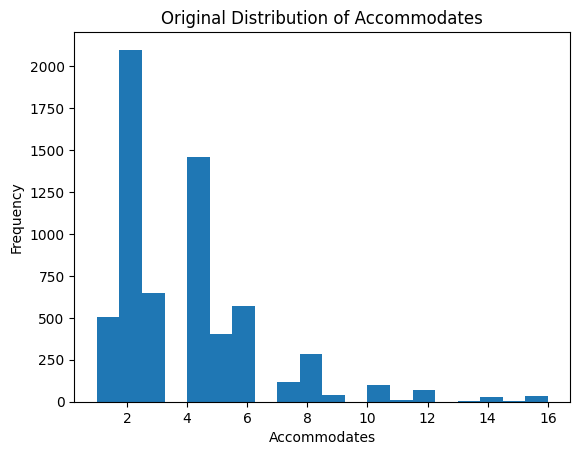

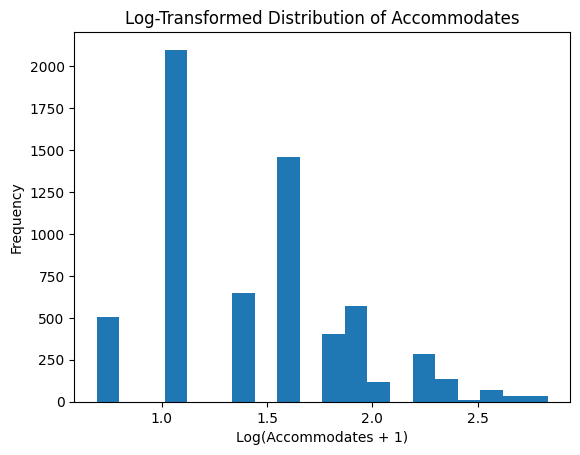

In [2]:
# Add code here 🔧
#accomodates (numeric column)
#hist 1
plt.figure()
plt.hist(df['accommodates'], bins=20)
plt.title("Original Distribution of Accommodates")
plt.xlabel("Accommodates")
plt.ylabel("Frequency")
plt.show()

#transformation (log)
df['accommodates_log'] = np.log1p(df['accommodates'])

#hist 2

plt.figure()
plt.hist(df['accommodates_log'], bins=20)
plt.title("Log-Transformed Distribution of Accommodates")
plt.xlabel("Log(Accommodates + 1)")
plt.ylabel("Frequency")
plt.show()


### ✍️ Your Response: 🔧
1. I chose the 'accommodate' numeric column that was skewed right

2. I applied a log transformation to reduce the impact of extreme values and make the data more normally distributed.

3. Now that the data is more normally distributed, it is more representative of the 'normal' accommodation size of listings that aren't large outliers, and makes the patterns easier to interpret.

## 3. Scale Two Numeric Columns

### Business framing:

If an analyst wanted to compare listing price to number of nights required, or create a model that weighs both, those values need to be on a similar scale.

### Do the following:
- Pick two numeric columns with different value ranges (e.g. one column may have a min of 0 and a max of 255; another column may have a min of 100 and a max of 400)
- Use Min-Max scaling on one column (the range should be “shrinked” down to just 0-1)
- Use Z-score Normalization (aka standardization) on the other column.
- Add 2 new columns to the dataset. These 2 new columns should be the ones you just created.

### In Your Response:
1. What two columns did you scale, and which methods did you use?
2. When might these scaled values be more useful than the originals?
3. Who at Airbnb might benefit from this transformation and why?

In [3]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Min-Max scale

minmax_scaler = MinMaxScaler()

df['availability_365_minmax'] = minmax_scaler.fit_transform(df[['availability_365']])


# Z-score scale

standard_scaler = StandardScaler()

df['price_zscore'] = standard_scaler.fit_transform(df[['price']])

#check

df[['price', 'price_zscore', 'availability_365', 'availability_365_minmax']].head()



,price,price_zscore,availability_365,availability_365_minmax
0,150.0,-0.076577,362,0.991781
1,61.0,-0.103458,364,0.997260
2,75.0,-0.099229,332,0.909589
3,90.0,-0.094699,351,0.961644
4,65.0,-0.102250,160,0.438356


### ✍️ Your Response: 🔧
1. I scaled price and availability_365 and used the minmax scaler for availability_365 and standard scaler (z-score) for price.

2. these scaled values would be more useful if you are trying to see how a listing compares relative to other listings. It would be useful for training an algorithm without introducing the magnitude differences that exist between price and availibility.

3. this could be useful for finance teams that want to create an algorithm that creates weighted scoring systems combining pricing and availability. WOuld be useful for fair comparisons to make booking predictions and pricing reccommendations.

## 4. Group a Numeric Column into Categories

### Business framing:  

Let’s say an Airbnb marketing team wants to segment listings by review activity. They don’t want exact numbers — they just want to know if a listing has “low,” “medium,” or “high” review volume.

### Do the following:

- Choose a numeric column that could be grouped (e.g., reviews, availability).
- You’ll want to group the values of this column into 3 or 4 bins
- Create a new column. The values of this column will be the labels: “Low”, “Medium”, and “High.” These labels should correspond to your bins.

### In Your Response:
1. What column did you group, and how many categories did you use?
2. Why might someone prefer this grouped view over raw numbers?
3. Who would this help at Airbnb, and how?


In [4]:
# Add code here 🔧

df['number_of_reviews_ltm'].describe()

#quintile binning ~equal binning

df['review_activity_level'] = pd.qcut(
    df['number_of_reviews_ltm'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

#check

df[['number_of_reviews_ltm', 'review_activity_level']].head()

,number_of_reviews_ltm,review_activity_level
0,0,Low
1,0,Low
2,39,High
3,5,Medium
4,0,Low


### ✍️ Your Response: 🔧
1. I grouped number_of_reviews_ltm (last 12 months) and I used three categories; low, medium, and high with quintile binning.

2. a grouped view makes the data easier to interpret at a glance, and it makes for easier decision-making and reduces outlier noise.

3. this could help the marketing team at airbnb because they could reach out to hosts with low review activity levels and give them optimization support, therefore increasing profit.

## 5. Create Two New Business-Relevant Variables

### Business framing:  

Stakeholders often want to know things like: What’s the cost per night? Are listings geared toward long-term stays? These kinds of features aren’t always in the dataset — analysts create them.

### Do the following:

- Think of two new columns you can create using the data you already have.
  - One might be a ratio or interaction between columns (e.g., price ÷ nights).
  - The other might be a flag based on a condition (e.g., stays longer than 30 days).
- Add the new columns to your DataFrame.

### In Your Response:
1. What two new columns did you create?
2. Who would use them (e.g., host, manager, or platform)?
3. How could they help someone make a better decision?

In [5]:
# Add code here 🔧

#cost per night

df['cost_per_night'] = df['price'] / df['minimum_nights']

# flag for stays longer than 30 days

df['long_term_stay_flag'] = df['minimum_nights'] > 30

#check

df[['price', 'minimum_nights', 'cost_per_night', 'long_term_stay_flag']].head()

,price,minimum_nights,cost_per_night,long_term_stay_flag
0,150.0,59,2.542373,True
1,61.0,31,1.967742,True
2,75.0,1,75.000000,False
3,90.0,4,22.500000,False
4,65.0,30,2.166667,False


### ✍️ Your Response: 🔧 🔧
1. I created cost per night (price / minimum_nights) and a flag variable for stays longer than 30 nights (minimum_nights > 30, T/F)

2. hosts could use these to evaluate their pricing and compare across similar listings.

3. this could help hosts make better pricing decisions by comparing their metrics with similar listings to find the optimal profit margin. It also allows Airbnb to optimize search filters and pricing strategies.


## 6. Encode a Categorical Column

### Business framing:  

Let’s say you’re helping the Airbnb data science team build a model to predict booking rates. Categorical columns like `room_type`, `neighbourhood`, or `cancellation_policy` can’t be used in models unless they’re converted to numbers.

### Do the following:
- Choose one categorical column from your dataset (e.g., room type or neighborhood group)
- Decide on an encoding method:
  - Use one-hot encoding for nominal (unordered) categories
  - Use ordinal encoding (a ranking) only if the categories have a clear order
- Apply the encoding using `pandas` or another tool
- Add the new encoded column(s) to your DataFrame

### ✍️ In your markdown:
1. What column did you encode and why?
2. What encoding method did you use?
3. How could this transformation help a pricing model, dashboard, or business report?



In [6]:
# Add code here 🔧
# neighborhood_cleansed column (categorical)

# 1-hot encoding
neighbourhood_dummies = pd.get_dummies(
    df['neighbourhood_cleansed'],
    prefix='neigh',
    drop_first=True
)

df = pd.concat([df, neighbourhood_dummies], axis=1)

#check

df.filter(like='neigh_').head()

,"neigh_Brookland, Brentwood, Langdon","neigh_Capitol Hill, Lincoln Park","neigh_Capitol View, Marshall Heights, Benning Heights","neigh_Cathedral Heights, McLean Gardens, Glover Park","neigh_Cleveland Park, Woodley Park, Massachusetts Avenue Heights, Woodland-Normanstone Terrace","neigh_Colonial Village, Shepherd Park, North Portal Estates","neigh_Columbia Heights, Mt. Pleasant, Pleasant Plains, Park View","neigh_Congress Heights, Bellevue, Washington Highlands","neigh_Deanwood, Burrville, Grant Park, Lincoln Heights, Fairmont Heights","neigh_Douglas, Shipley Terrace",...,"neigh_Shaw, Logan Circle","neigh_Sheridan, Barry Farm, Buena Vista","neigh_Southwest Employment Area, Southwest/Waterfront, Fort McNair, Buzzard Point","neigh_Spring Valley, Palisades, Wesley Heights, Foxhall Crescent, Foxhall Village, Georgetown Reservoir","neigh_Takoma, Brightwood, Manor Park","neigh_Twining, Fairlawn, Randle Highlands, Penn Branch, Fort Davis Park, Fort Dupont","neigh_Union Station, Stanton Park, Kingman Park","neigh_West End, Foggy Bottom, GWU","neigh_Woodland/Fort Stanton, Garfield Heights, Knox Hill","neigh_Woodridge, Fort Lincoln, Gateway"
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


### ✍️ Your Response: 🔧
1. I encoded neighborhood_cleansed because it was more organized than the 'neighborhood' column, and I used 1-hot encoding because there is no ordinal rank between the different neighborhoods.
2. I used 1-hot encoding
3. by 1-hot encoding this categorical variable into a numeric, non-ordinal variable, it enables the model to learn price differences by neighborhood, and simplifies filtering for business reports and dashboards as well as sorting for highest performing neighborhoods.

## 7. Export Cleaned Data

Before wrapping up, export your cleaned Airbnb dataset to a CSV file. You'll need this file for **Assignment 11**, where you'll use the data in a regression model.

### Do the following:
Make sure your data has:
- Cleaned and consistent column values
- Proper data types for each column
- Any unnecessary columns removed

This file should be the version of your dataset that you’d feel confident sharing with a teammate or using for deeper analysis.



```
# Explanation:
# - "cleaned_airbnb_data_7.csv" is the name of the file that will be saved
# - index=False prevents pandas from writing row numbers into the CSV
# - The file will be saved to your working directory (in Colab, you'll need to download it manually. Once you see the data in your files tab, just click on the three dots, then click “download”)
# - YOU MAY NEED TO PRESS “RUN” MULTIPLE TIMES IN ORDER FOR IT TO SHOW UP
# - FOR SOME DEVICES, IT MAY TAKE A FEW MINUTES BEFORE YOUR FILE SHOWS UP

```

In [7]:
# export csv here 🔧
info = df.info()
print(info)

isNull = df.isnull().sum()
print(isNull)

df.to_csv("cleaned_airbnb_data_7.csv", index=False)



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6374 entries, 0 to 6373
Columns: 123 entries, id to neigh_Woodridge, Fort Lincoln, Gateway
dtypes: bool(42), category(1), float64(28), int64(20), object(32)
memory usage: 4.2+ MB
None
id                                                                                      0
listing_url                                                                             0
scrape_id                                                                               0
last_scraped                                                                            0
source                                                                                  0
                                                                                       ..
neigh_Twining, Fairlawn, Randle Highlands, Penn Branch, Fort Davis Park, Fort Dupont    0
neigh_Union Station, Stanton Park, Kingman Park                                         0
neigh_West End, Foggy Bottom, GWU             

## 8. Reflection

You’ve applied the same kinds of transformation techniques used in real Airbnb analytics projects — from pricing engines to host tools to tourism dashboards.

Now step back and reflect.

### In Your Response:
1. What transformation step felt most important or interesting?
2. Which of your changes would be most useful to a host, analyst, or city planner?
3. If you were going to build a tool or dashboard, what would you do next with this data?
4. How does this relate to your customized learning outcome you created in canvas?



### ✍️ Your Response: 🔧

1. the most important transformation in my opinion was creating new variables like price per night and a flag variable for stays longer than 30 days. I think that creating new variables from existing ones can give deeper insight and analysis, especially for training models that help optimize pricing and profit.

2. the most useful change would likely be the 1-hot encoding of the different neighborhoods, because it allows enables a model to compare pricing to neighborhoods and that would be useful for a host and analysts. City planners could also sort and filter by neighborhoods to further analyze what makes the neigbhorhood more desirable.

3. I would build an AI model with unsupervised learning to see what kind of patterns it picks up on in the data. This would be useful for unseen insights and useful for creating tools for a dashboard.
4. This relates to my customized learning outcome I created at the beginning of the semester because I want to have a career in IS, and knowing how to use Python for data analysis / cleaning is an important skill to have for that. Now I know how 1-hot encoding works and the fundamental steps for preparing data for AI modeling.



## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [10]:
!jupyter nbconvert --to html "assignment_07_RichmondRiley.ipynb"

[NbConvertApp] Converting notebook assignment_07_RichmondRiley.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 408235 bytes to assignment_07_RichmondRiley.html
